## Concept-based explainability

Traditional explainability methods in deep learning, such as saliency maps or pixel-wise gradients, explain predictions at a very low level. While these methods can show where a model is looking, they often fail to explain why a decision was made in a way that aligns with human reasoning. Humans do not think in terms of pixels or gradients; instead, they reason using high-level concepts such as “clouds,” “roads,” “edges,” or “textures.”

Concept-Based Explainable AI aims to bridge this gap by explaining model behavior in terms of human-interpretable concepts. Rather than asking how important each pixel is, CB-XAI asks questions like: Does the model rely on clouds when predicting airplanes? or Is the presence of roads influencing automobile predictions?

In [ ]:
import subprocess, sys

# We install **captum** . Using `sys.executable` ensures pip targets the exact kernel that is running this notebook,
# so the package is always importable after install.

# captum 0.8.0 is pure Python and works fine with numpy 2.x.
# --no-deps skips captum's conservative numpy<2 pin so numpy is not downgraded.
# --break-system-packages is required on PEP-668-protected Pythons (e.g. Homebrew);
#   it is silently ignored on Colab, virtualenvs, and conda envs.
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', 'captum', '--no-deps', '-q',
     '--break-system-packages']
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
import torchvision
import torchvision.transforms as T
import os
import numpy as np
from tqdm import tqdm

from captum.concept import TCAV, Concept
from captum.attr import LayerIntegratedGradients

### TCAV — Testing with Concept Activation Vectors

TCAV operates in the **activation space** of a neural network rather than the input space. For a chosen hidden layer, it collects activations for a set of images that represent a human-chosen concept (e.g. *stripes*) and for a set of random images. A linear classifier is trained to separate the two, and the normal vector of this classifier: the **Concept Activation Vector (CAV)**, is the direction in feature space that corresponds to "more of this concept".

TCAV then measures how sensitive the model's output is along that direction by computing directional derivatives of the class logit with respect to the layer activations. If moving in the direction of the concept consistently increases the output score for a class, the model is said to *rely on* that concept when predicting that class.

Two important properties:

1. TCAV is a **global**, class-level explanation, not a per-image one, which means its output is a statistic over many examples.
2. The concept images and the classification images can (and usually should) come from **different sources**. That way the CAV captures the concept itself, not whatever shortcuts co-occur with it in the training set.

**CIFAR-10** is a standard image-classification benchmark: 60,000 colour images of size 32×32 pixels, split into 50,000 training and 10,000 test samples across 10 classes — *airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck*. The task is to predict the class label of each image from its pixel values.

In this part we train a small convolutional network on **the full 10-class CIFAR-10 dataset**. Training on all 10 classes (rather than just airplane vs automobile) gives the model a richer feature space, which is what TCAV needs for concept directions to be stable.

We then ask the classic TCAV question: **does the model rely on `cloud` features when predicting the `airplane` class?** We follow the original TCAV paper's methodology (Kim et al., 2018) and compare cloud against a **null distribution** built from random-vs-random CAVs. The intuition: a CAV trained between two random samples from the same distribution has no meaningful direction, so its sign_count should sit at ≈ 0.5. If cloud's sign_count distribution is clearly *above* the null, the concept is driving the prediction.

This statistical framing rather than hand-picking a single control concept is the right way to get a robust answer from TCAV.

In [ ]:
# import os
# import shutil
# shutil.rmtree(os.path.expanduser("~/.captum/concept"), ignore_errors=True)
# in case you are reruning the notebook, clear from the previous run

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# CIFAR-10 normalization statistics — pixel values are shifted and scaled so
# each channel has zero mean and unit variance across the training set.
MEAN = [0.4914, 0.4822, 0.4465]
STD  = [0.2023, 0.1994, 0.2010]

# Training transform: light augmentation (random crop + horizontal flip) to
# improve generalisation.  Evaluation transform: normalisation only.
train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=True, transform=train_transform
)
testset  = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=eval_transform
)

CLASS_NAMES = trainset.classes            # ['airplane', 'automobile', 'bird', ...]
AIRPLANE    = CLASS_NAMES.index("airplane")   # integer class index used by TCAV
AUTOMOBILE  = CLASS_NAMES.index("automobile")
NUM_CLASSES = len(CLASS_NAMES)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=128, shuffle=False, num_workers=2)

print("classes:", CLASS_NAMES)
print("train:", len(trainset), "  test:", len(testset))

classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train: 50000   test: 10000


We define a small three-layer convolutional network with a 10-class head. No BatchNorm and no dropout because although useful, they require us to remember `model.eval()` before any inference step, and Captum's TCAV **does not** call `eval()` for us (it just runs whatever mode the model is in).

The key detail for TCAV is that `conv3` (the deepest convolution) is accessible as an attribute. TCAV analyses its activations, since by that layer the network has formed features abstract enough to correspond to human concepts.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.features = nn.Sequential(
            self.conv1, nn.ReLU(), nn.MaxPool2d(2),   # 32 -> 16
            self.conv2, nn.ReLU(), nn.MaxPool2d(2),   # 16 -> 8
            self.conv3, nn.ReLU(), nn.MaxPool2d(2),   #  8 -> 4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x, *args, **kwargs):
        x = self.features(x)
        return self.classifier(x)


model = SimpleCNN().to(DEVICE)

We train the model for 10 epochs on all 50k CIFAR-10 images. This is enough for the test accuracy to reach ~75-80%, which is plenty for the feature space to stabilise. (Remember, we don't need state-of-the-art classification, we just need features that are *consistent enough* for CAVs to latch onto.)

In [ ]:
torch.manual_seed(0)            # reproducible model weights -> reproducible CAVs
np.random.seed(0)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for x, y in tqdm(trainloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)

    model.eval()
    t_correct, t_total = 0, 0
    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = model(x).argmax(dim=1)
            t_correct += (preds == y).sum().item()
            t_total   += y.size(0)

    print(f"epoch {epoch+1:02d}  train_acc={correct/total:.3f}  test_acc={t_correct/t_total:.3f}")

epoch 01  train_acc=0.436  test_acc=0.565


epoch 02  train_acc=0.583  test_acc=0.654


epoch 03  train_acc=0.653  test_acc=0.697


epoch 04  train_acc=0.689  test_acc=0.723


epoch 05  train_acc=0.716  test_acc=0.745


epoch 06  train_acc=0.734  test_acc=0.741


epoch 07  train_acc=0.749  test_acc=0.759


epoch 08  train_acc=0.761  test_acc=0.780


epoch 09  train_acc=0.775  test_acc=0.783


epoch 10  train_acc=0.783  test_acc=0.790


We pick **cloud** as our concept and ask: *does the model rely on cloud features when predicting airplanes?*

To answer it, we train a CAV by pairing cloud images against a set of random images : this pair is what Captum calls an **experimental set** `[cloud, random_i]`. We train a linear classifier and the CAV is the direction in activation space that separates the two groups. TCAV then checks, for each airplane test image, whether pushing its activations along the cloud CAV increases the airplane score. The fraction of test images where it does is the **sign_count**:
- **sign_count ≈ 1.0** → cloud consistently helps predict airplane → the model relies on it.
- **sign_count ≈ 0.5** → no consistent effect → irrelevant concept (coin-flip).

A single CAV can be noisy — its direction shifts depending on which random images happen to be in the baseline. So we train **8 independent CAVs**, one for each of 8 different random baselines, and collect a *distribution* of 8 sign_counts rather than trusting a single number.

To know whether those sign_counts are meaningful, we also pair the random baselines *against each other*. Since in this case both sides are random, these CAVs point in arbitrary directions and their sign_counts sit around 0.5 — our **null distribution**. A t-test then tells us whether cloud’s distribution is significantly above the null (p < 0.05).

In [ ]:
# We use CIFAR-100 as the source of concept images because it contains
# fine-grained classes (including "cloud") that don't appear in CIFAR-10.
# This keeps the concept images completely separate from the training data
# the model was trained on.
cifar100 = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=eval_transform
)

CIFAR100_LABELS = cifar100.classes
cifar100_targets = np.array(cifar100.targets)

def get_concept_subset(class_name, max_samples=500, seed=0):
    """returns a subset of CIFAR-100 images belonging to a given class"""
    if class_name not in CIFAR100_LABELS:
        raise ValueError(f"Unknown CIFAR-100 class: {class_name}")
    cid = CIFAR100_LABELS.index(class_name)
    idxs = np.where(cifar100_targets == cid)[0]
    rng = np.random.default_rng(seed)
    rng.shuffle(idxs)
    return Subset(cifar100, idxs[:max_samples].tolist())

POSITIVE_CONCEPT = "cloud"
pos_concept_set  = get_concept_subset(POSITIVE_CONCEPT, max_samples=500, seed=1)

# Random baselines: uniform random over all OTHER CIFAR-100 classes
# We exclude the cloud class so that random baselines contain no cloud images.
EXCLUDED_IDS    = {CIFAR100_LABELS.index(POSITIVE_CONCEPT)}
non_concept_idx = np.where(~np.isin(cifar100_targets, list(EXCLUDED_IDS)))[0]

rng = np.random.default_rng(42)
rng.shuffle(non_concept_idx)

# 8 disjoint random subsets of 200 images each.  We need multiple subsets so
# we can train independent CAVs and get a distribution of sign_counts.
N_RANDOM_SETS = 8
PER_SET       = 200

random_subsets = [
    Subset(cifar100, non_concept_idx[i*PER_SET:(i+1)*PER_SET].tolist())
    for i in range(N_RANDOM_SETS)
]

print(f"{POSITIVE_CONCEPT:8s}: {len(pos_concept_set)} images")
for i, rs in enumerate(random_subsets):
    print(f"random_{i}: {len(rs)} images")

cloud   : 500 images
random_0: 200 images
random_1: 200 images
random_2: 200 images
random_3: 200 images
random_4: 200 images
random_5: 200 images
random_6: 200 images
random_7: 200 images


We wrap the positive concept and every random baseline as Captum `Concept` objects. Concept IDs must be unique across every experimental set we'll build.

In [ ]:
cloud = Concept(
    id=0, name=POSITIVE_CONCEPT,
    data_iter=DataLoader(pos_concept_set, batch_size=32, shuffle=True),
)

random_concepts = [
    Concept(
        id=100 + i,
        name=f"random_{i}",
        data_iter=DataLoader(rs, batch_size=32, shuffle=True),
    )
    for i, rs in enumerate(random_subsets)
]

# Kept around for the ACE section at the bottom of the notebook.
random = random_concepts[0]

#### Visualising the concept images

Before running TCAV, it is worth looking at what the concept and random images actually look like. This builds intuition for what the CAV is being trained to separate.

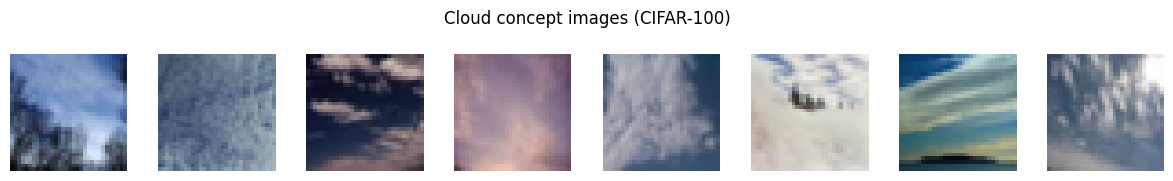

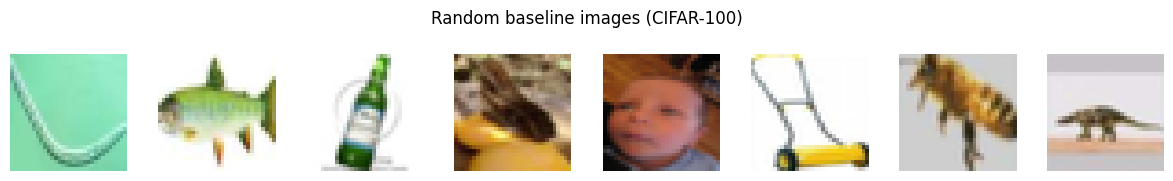

In [ ]:
import matplotlib.pyplot as plt

_MEAN_VIS = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
_STD_VIS  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

def denorm_vis(x):
    """Undo CIFAR normalisation for display."""
    return (x * _STD_VIS + _MEAN_VIS).clamp(0, 1)

def show_concept_samples(concept, n=8, title=""):
    """Pull one batch from a Concept's DataLoader and display the first n images."""
    batch = next(iter(concept.data_iter))
    # DataLoader may return (images,) or (images, labels) depending on the dataset.
    imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
    imgs = imgs[:n]

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.8))
    fig.suptitle(title, fontsize=12)
    for ax, img in zip(axes, imgs):
        ax.imshow(denorm_vis(img).permute(1, 2, 0).numpy())
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_concept_samples(cloud,              title="Cloud concept images (CIFAR-100)")
show_concept_samples(random_concepts[0], title="Random baseline images (CIFAR-100)")

TCAV scores are class-specific: for each concept we ask *"how does moving along its CAV affect the prediction for the airplane class?"*.

We collect 200 test images of CIFAR-10 airplanes.

In [ ]:
test_images = []
for x, y in testloader:
    test_images.append(x[y == AIRPLANE])
test_images = torch.cat(test_images)[:200]
print("airplane test batch:", tuple(test_images.shape))

airplane test batch: (200, 3, 32, 32)


TCAV is more stable on CPU (multi-processing, classifier caching) and we **must** explicitly put the model in `eval()` mode before calling into Captum. Captum does not call `model.eval()` for us; if the model is left in train mode, any BatchNorm or Dropout layers will produce different activations on every forward pass, and the CAVs will be essentially noise.

In [ ]:
model = model.cpu()
model.eval()

test_images = test_images.cpu()

The TCAV object is configured to analyse `conv3`, the deepest convolution in our network, where features are most likely to correspond to human-interpretable concepts. We use Layer Integrated Gradients as the attribution method, so TCAV will measure how the airplane logit changes with respect to `conv3` activations.

In [ ]:
import tempfile
from captum.concept import TCAV
from captum.attr import LayerIntegratedGradients

layer_name = "conv3"

# Fresh temp dir per run so Captum doesn't silently reuse stale CAVs.
_tcav_save = tempfile.mkdtemp(prefix="tcav_main_")

tcav = TCAV(
    model=model,
    layers=[layer_name],
    layer_attr_method=LayerIntegratedGradients(model, model.conv3),
    device="cpu",
    save_path=_tcav_save,
)

/usr/local/lib/python3.12/dist-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


We now build the experimental sets, train all CAVs, and score them:

/usr/local/lib/python3.12/dist-packages/captum/_utils/models/linear_model/train.py:409: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


TCAV on the AIRPLANE class
group                n    sign_count            
--------------------------------------------------------------------
cloud                8    0.854 ± 0.065
random (null)        7    0.469 ± 0.137

two-sample t-test:  t = +6.296   p = 0.0002072
  -> cloud's sign_count is SIGNIFICANTLY above the random null (p < 0.05)
     the model is using cloud features to predict airplane.


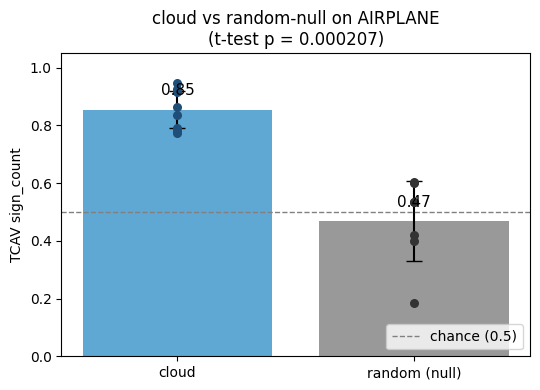

In [ ]:
from collections import defaultdict
from scipy import stats as scipy_stats

# Build experimental sets
# Cloud CAVs: pair cloud with each random baseline independently.
# Each pair trains one CAV → one sign_count estimate for cloud.
cloud_sets = [[cloud, rc] for rc in random_concepts]

# Null CAVs: pair random_0 with each other random baseline.
# Since both sides are random, these CAVs have no meaningful direction
# → their sign_counts define the "noise floor" (null distribution).
null_ref  = random_concepts[0]
null_sets = [[null_ref, rc] for rc in random_concepts[1:]]

experimental_sets = cloud_sets + null_sets   # 15 total

# Train all CAVs
# compute_cavs trains one binary linear classifier per experimental set.
# force_train=True ignores any cached CAVs from a previous run.
tcav.compute_cavs(
    experimental_sets=experimental_sets,
    processes=1,
    force_train=True,
)

# Run TCAV scoring
# For each CAV, TCAV computes the directional derivative of the airplane
# logit with respect to conv3 activations along the CAV direction, then
# reports the fraction of test images where this derivative is positive
# (= sign_count).
scores = tcav.interpret(
    inputs=(test_images,),
    experimental_sets=experimental_sets,
    target=AIRPLANE,
    processes=1,
)

# Collect sign_counts per group
# The scores dict is keyed by "{id_A}-{id_B}" strings; we use the first id
# to route each score to either the cloud or null group.
cloud_scores = []
null_scores  = []
for pair_key, layer_dict in scores.items():
    first_id = int(pair_key.split("-")[0])
    for _, stats in layer_dict.items():
        s = stats["sign_count"][0].item()
        if first_id == cloud.id:
            cloud_scores.append(s)
        elif first_id == null_ref.id:
            null_scores.append(s)

cloud_scores = np.array(cloud_scores)
null_scores  = np.array(null_scores)

# summary table
print("TCAV on the AIRPLANE class")
print("=" * 68)
print(f"{'group':<20} {'n':<4} {'sign_count':<22}")
print("-" * 68)
print(f"{'cloud':<20} {len(cloud_scores):<4} "
      f"{cloud_scores.mean():.3f} ± {cloud_scores.std():.3f}")
print(f"{'random (null)':<20} {len(null_scores):<4} "
      f"{null_scores.mean():.3f} ± {null_scores.std():.3f}")

#  Statistical test
# Welch's t-test (equal_var=False) does not assume equal variances, which is
# appropriate here since the two groups may have different spreads.
t_stat, p_value = scipy_stats.ttest_ind(cloud_scores, null_scores, equal_var=False)
print()
print(f"two-sample t-test:  t = {t_stat:+.3f}   p = {p_value:.4g}")
if p_value < 0.05:
    print("  -> cloud's sign_count is SIGNIFICANTLY above the random null (p < 0.05)")
    print("     the model is using cloud features to predict airplane.")
else:
    print("  -> cloud's sign_count is NOT significantly above the random null")
    print("     TCAV has no evidence the model is using cloud features here.")


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(
    ["cloud", "random (null)"],
    [cloud_scores.mean(), null_scores.mean()],
    yerr=[cloud_scores.std(), null_scores.std()],
    capsize=6,
    color=["#5fa8d3", "#999999"],
)
# Scatter the individual sign_counts on top of each bar so the reader can
# see how consistent the results are across different random baselines.
ax.scatter([0] * len(cloud_scores), cloud_scores, color="#1f4e79", zorder=3, s=30)
ax.scatter([1] * len(null_scores),  null_scores,  color="#333333", zorder=3, s=30)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance (0.5)")
ax.set_ylim(0, 1.05)
ax.set_ylabel("TCAV sign_count")
ax.set_title(f"cloud vs random-null on AIRPLANE\n"
             f"(t-test p = {p_value:.3g})")
ax.legend(loc="lower right")

for x, mean in enumerate([cloud_scores.mean(), null_scores.mean()]):
    ax.text(x, mean + 0.05, f"{mean:.2f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

Each dot is one independently-trained CAV; bars show the mean ± std across all dots in that group.

- The **cloud dots** all sit clearly above 0.5: every CAV trained with a different random baseline agrees that moving activations in the cloud direction raises the airplane logit. The cloud concept is not a fluke of one particular random sample.
- The **null dots** are around 0.5: when both sides of the classifier come from the same random population, the resulting CAV points in an arbitrary direction and the derivative is positive or negative roughly half the time — exactly what we expect from noise.
- The **t-test p-value** gives a formal answer: the two *distributions* (not just their means) are significantly separated (p < 0.05), so we can conclude that the model genuinely uses cloud-like features when predicting the airplane class.


### ACE (Automatic Concept-based Explanations)

TCAV is powerful but has a fundamental limitation: **you have to know in advance which concepts to test**. You need a labelled set of "cloud" images, a labelled set of "road" images, and so on. You can only test hypotheses you already thought of.

**ACE (Ghorbani et al., 2019)** removes that bottleneck. Instead of asking the user to supply the concepts, ACE discovers them automatically from the training data of the target class.

How it works:
- **Segment** images of the target class into small fragments. The original paper uses SLIC super-pixels at several scales; for simplicity, this tutorial uses a regular grid of patches.
- **Embed** each fragment in a feature space, typically we use the activation space of the network we want to explain, such that fragments the model considers similar end up close together.
- **Cluster** the fragments across many images. Each coherent cluster is a *candidate concept*.
- **Score** each candidate concept with TCAV against the target class. Clusters with a high TCAV score are the concepts the model actually uses.
- **Visualise** the members of each high-scoring cluster. Only at this last step we can see if the clusters make any sense to us.

The key conceptual shift is that the concepts **emerge from the model's own representations**, rather than being imposed from outside. Whatever ends up clustered is what the network treats as "similar", which means ACE can also surface *unwanted* shortcuts the model has latched onto.

#### Extracting patches from the training images

We slide a small window over every image to produce overlapping patches. The trade-off opposed to the SLIC super-pixels is that grid patches can cut through objects, whereas super-pixels tend to respect object boundaries.

With a 32×32 CIFAR-10 image, a `patch_size=16, stride=8` window gives a 3×3 = 9 patches per image.

In [ ]:
def extract_patches(img, patch_size=16, stride=8):
    patches = []
    C, H, W = img.shape
    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patches.append(img[:, i:i+patch_size, j:j+patch_size])
    return patches

For the clustering step we need a feature space where *visually similar patches land close together*.

One of the simplest ways to do this is by considering simple colour statistics. For each patch, compute the mean and standard deviation of each RGB channel. This captures the *dominant colour palette* of a patch, which on 16×16 CIFAR fragments is the single most informative signal anyway.
Clusters end up grouped by "sky-like bluish patches", "white/grey airplane-body patches", "dark ground strips", etc. which is exactly the kind of interpretable clustering ACE wants, and it matches how a human would eyeball these tiny patches.

Other options would include random conv filters or trained feature detectors.


In [ ]:
def color_features(patch):
    mean = patch.mean(dim=(1, 2))     # (3,)
    std  = patch.std(dim=(1, 2))      # (3,)
    return torch.cat([mean, std]).numpy()   # (6,)

#### Sampling airplane images and computing colour-feature vectors for every patch

We sample 1000 airplane images from the training set, slide a 16×16 window across each (stride 8, giving 9 patches per image) and compute a 6-dimensional colour descriptor (mean and std of each RGB channel) for every patch.

In [ ]:
NUM_ACE_IMAGES = 1000

# Filter airplane images only — TCAV will score the ACE concepts on airplane.
airplane_train_idxs = [i for i in range(len(trainset))
                       if trainset.targets[i] == AIRPLANE]
rng = np.random.default_rng(42)
airplane_sample = rng.choice(airplane_train_idxs, NUM_ACE_IMAGES, replace=False)

ace_dataset = Subset(trainset, airplane_sample.tolist())
ace_loader  = DataLoader(ace_dataset, batch_size=32, shuffle=False)

patch_imgs     = []   # raw patches (for visualisation)
patch_features = []   # 6-D colour descriptors (for clustering)
patch_img_ids  = []   # source image id, used for dedup in viz

global_img_id = 0
for x, _ in tqdm(ace_loader, desc="ACE: extracting patches"):
    for b in range(x.size(0)):
        img = x[b]
        for p in extract_patches(img):       # 16x16, stride 8 → 9 patches
            patch_imgs.append(p.numpy())
            patch_features.append(color_features(p))
            patch_img_ids.append(global_img_id)
        global_img_id += 1

patch_features = np.array(patch_features)
print(f"collected {len(patch_imgs)} patches from {global_img_id} airplane images")
print(f"feature dim = {patch_features.shape[1]}  (3 channel means + 3 channel stds)")

ACE: extracting patches: 100%|██████████| 32/32 [00:00<00:00, 44.20it/s]

collected 9000 patches from 1000 airplane images
feature dim = 6  (3 channel means + 3 channel stds)


#### Clustering the patches into candidate concepts

KMeans groups patches that are close in 6-D colour space. Each cluster is a **candidate concept**: a set of patches that share a colour palette. We set `k = 8` here.
We also compute the distance from every patch to every centroid so we can later pick the most representative (most central) patches when visualising each cluster.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

NUM_ACE_CONCEPTS = 8

kmeans = KMeans(n_clusters=NUM_ACE_CONCEPTS, n_init=10, random_state=0)
ace_concept_ids = kmeans.fit_predict(patch_features)

# Distance of each patch to every centroid — used to pick representative
# patches for visualisation.
distances = pairwise_distances(
    patch_features, kmeans.cluster_centers_, metric="euclidean",
)

# Quick size sanity check
for c in range(NUM_ACE_CONCEPTS):
    print(f"cluster {c}: {(ace_concept_ids == c).sum()} patches")

cluster 0: 1454 patches
cluster 1: 1345 patches
cluster 2: 1262 patches
cluster 3: 1434 patches
cluster 4: 890 patches
cluster 5: 681 patches
cluster 6: 896 patches
cluster 7: 1038 patches


#### Wraping each cluster as a Captum `Concept`

To score a cluster with TCAV, it has to look like any other hand-labelled concept: a `Concept` object with a `data_iter` that yields images in the model's input format. We take the 100 patches closest to each centroid, up-sample them to 32×32, wrap them in a `TensorDataset` / `DataLoader`, and expose them as `Concept` objects just like `cloud` earlier.

In [ ]:
ace_concepts = []

for c in range(NUM_ACE_CONCEPTS):
    idxs = np.where(ace_concept_ids == c)[0]
    # Take the 100 patches closest to the centroid — the most representative.
    idxs = idxs[np.argsort(distances[idxs, c])][:100]

    concept_patches = torch.stack(
        [torch.tensor(patch_imgs[i]) for i in idxs]
    )

    # Up-sample 12x12 patches to 32x32 so the main model can ingest them.
    concept_patches_up = F.interpolate(
        concept_patches, size=(32, 32), mode="bilinear", align_corners=False
    )

    dataset = TensorDataset(concept_patches_up)
    loader  = DataLoader(dataset, batch_size=32, shuffle=True)

    ace_concepts.append(
        Concept(
            id=10 + c,              # keep away from TCAV-section IDs (0, 1, 100..)
            name=f"ace_concept_{c}",
            data_iter=loader,
        )
    )

#### Scoring each discovered concept with TCAV

Now for every discovered cluster we train a CAV against a random baseline and ask "how much does moving in this direction push the airplane logit up?". Clusters that score high are concepts the model *actually uses* for the airplane class.


Notes:
- Captum caches CAVs by `(layer, experimental set)`. If we reused the same `random` object across every ACE concept, we'd get the cached CAV from the first call back for every subsequent one. We side-step this by `copy.deepcopy`-ing `random` and giving each copy a unique `id`.
- The TCAV score we print below is `sign_count`, which is the fraction of test images where the directional derivative is positive. Near 0.5 ≈ "irrelevant concept", near 1.0 ≈ "strongly pushes the prediction toward airplane".

In [ ]:
import copy, tempfile

_ace_save = tempfile.mkdtemp(prefix="tcav_ace_")

tcav_ace = TCAV(
    model=model,
    layers=[layer_name],   # conv3, reused from the TCAV section
    layer_attr_method=LayerIntegratedGradients(model, model.conv3),
    device="cpu",
    save_path=_ace_save,
)

ace_concept_scores = []

for i, concept in enumerate(ace_concepts):
    random_copy = copy.deepcopy(random)
    random_copy.id = 300 + i

    tcav_ace.compute_cavs(
        experimental_sets=[[concept, random_copy]],
        processes=1,
        force_train=True,
    )

    scores = tcav_ace.interpret(
        inputs=(test_images,),
        experimental_sets=[[concept, random_copy]],
        target=AIRPLANE,
        processes=1,
    )

    for _, layer_dict in scores.items():
        for _, stats in layer_dict.items():
            sign_count = stats["sign_count"][0].item()
            ace_concept_scores.append((concept.id, sign_count))

ace_concept_scores.sort(key=lambda x: x[1], reverse=True)

print("ACE concepts ranked by TCAV on the AIRPLANE class")
print("=" * 50)
for cid, score in ace_concept_scores:
    print(f"  ace_concept_{cid - 10}: TCAV = {score:.3f}")

/usr/local/lib/python3.12/dist-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


ACE concepts ranked by TCAV on the AIRPLANE class
  ace_concept_0: TCAV = 0.945
  ace_concept_5: TCAV = 0.935
  ace_concept_2: TCAV = 0.930
  ace_concept_6: TCAV = 0.815
  ace_concept_7: TCAV = 0.755
  ace_concept_4: TCAV = 0.685
  ace_concept_3: TCAV = 0.575
  ace_concept_1: TCAV = 0.465


#### Visualising the top concepts

TCAV told us *which* clusters matter, now we have to look at them to understand *what* they are. Each row below is one of the top-K concepts. The images in the row are the patches nearest its cluster centroid. Now we can inspect each row and decide whether the patches look like sky, wing edges, road texture, and so on.

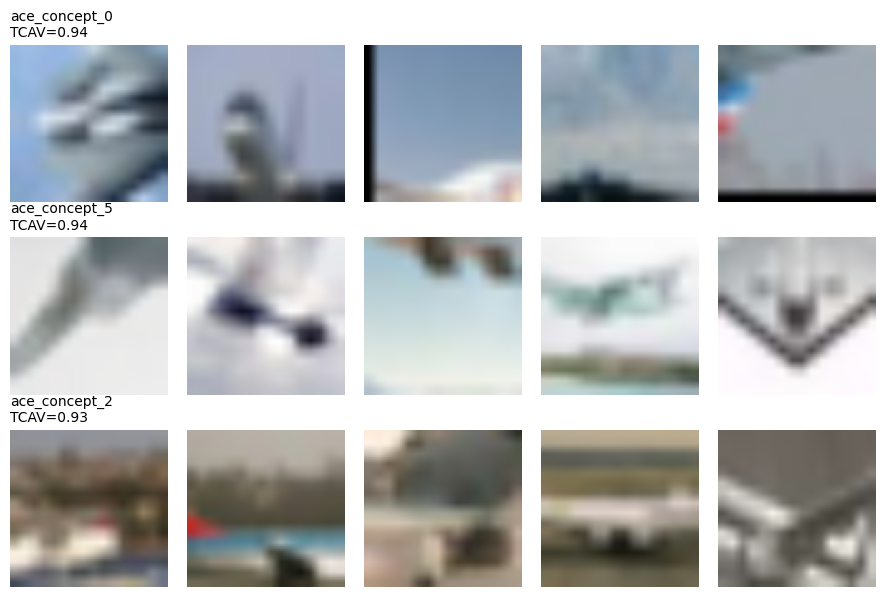

In [ ]:
import matplotlib.pyplot as plt

_MEAN_T = torch.tensor(MEAN).view(3, 1, 1)
_STD_T  = torch.tensor(STD).view(3, 1, 1)

def denorm(x):
    return (x * _STD_T + _MEAN_T).clamp(0, 1)

def show_top_ace_concepts(patch_imgs, concept_ids, patch_img_ids, ace_scores, distances, top_k=4, n_examples=6, display_size=96):
    """Display the top-K ACE concepts ranked by TCAV score.

    Patches are denormalized (back into natural RGB), then bilinearly
    upsampled to `display_size` pixels per side so they are actually
    readable — the raw 16x16 patches are too small to see anything.
    """
    fig, axes = plt.subplots(top_k, n_examples,
                             figsize=(n_examples * 1.8, top_k * 2.0))
    if top_k == 1:
        axes = np.array([axes])

    for row, (concept_id, score) in enumerate(ace_scores[:top_k]):
        cluster_idx = concept_id - 10
        idxs = np.where(concept_ids == cluster_idx)[0]
        idxs = sorted(idxs, key=lambda i: distances[i, cluster_idx])

        # Dedup source images so each row shows patches from different planes.
        used_imgs = set()
        selected  = []
        for idx in idxs:
            img_id = patch_img_ids[idx]
            if img_id in used_imgs:
                continue
            selected.append(idx)
            used_imgs.add(img_id)
            if len(selected) == n_examples:
                break

        for col in range(n_examples):
            ax = axes[row, col]
            ax.axis("off")
            if col >= len(selected):
                continue
            patch = torch.tensor(patch_imgs[selected[col]])
            patch = denorm(patch)
            patch_up = F.interpolate(
                patch.unsqueeze(0), size=(display_size, display_size),
                mode="bilinear", align_corners=False,
            ).squeeze(0)
            ax.imshow(np.transpose(patch_up.numpy(), (1, 2, 0)))
            if col == 0:
                ax.set_title(f"ace_concept_{cluster_idx}\nTCAV={score:.2f}",
                             fontsize=10, loc="left")

    plt.tight_layout()
    plt.show()


show_top_ace_concepts(
    patch_imgs,
    ace_concept_ids,
    patch_img_ids,
    ace_concept_scores,
    distances,
    top_k=3,
    n_examples=5,
)

### Summary

Both TCAV and ACE are concept-based explainability methods that move beyond pixel-level attributions and instead explain a model's behaviour in terms of human-interpretable concepts, but they differ fundamentally in where those concepts come from.

**TCAV** (Kim et al., 2018) is a *hypothesis-driven* method. The user supplies labelled image sets for each concept they want to test (e.g. "clouds", "stripes"). A linear classifier is trained in the activation space of a chosen layer to separate concept images from random images, and the resulting normal vector, the Concept Activation Vector, encodes the direction in feature space that corresponds to that concept. TCAV then measures how sensitive the model's class output is along that direction via directional derivatives. The outcome is a global, class-level score: it tells you whether the model *as a whole* relies on a given concept when predicting a given class, not why it made any single prediction. Because the user defines the concepts, TCAV can only test ideas already thought of; it cannot surface unexpected patterns.

**ACE** (Ghorbani et al., 2019) is a *discovery-driven* method that removes this bottleneck. It automatically finds the concepts by segmenting training images of the target class into patches, embedding those patches in a feature space, and clustering them. Each coherent cluster is a candidate concept that emerges from the model's own representations, no human labelling required. ACE then scores each discovered concept with TCAV to identify which ones the model actually uses. Crucially, because the concepts come from the model itself, ACE can surface unexpected shortcuts or spurious correlations that a human analyst would never have thought to test.

In short: TCAV answers *"does this concept matter?"* for concepts you already have in mind, while ACE answers *"what concepts does the model care about?"* without any prior assumptions. ACE essentially automates the concept-collection step of TCAV and feeds its output back into TCAV for scoring, making the two methods complementary rather than competing.